## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

In [2]:
real_or_simulated = 'simulated' #simulated / real / all
keep_sample_together = True #Should all 15 slices from the same sample go together to the same set (train/test)?
remove_outliers = False

if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
if remove_outliers:
    outliers = 'outliers_removed'
else:
    outliers = 'outliers_present'

In [3]:
outliers_indices = {
    'simulated': list(range(1035, 1050)) + list(range(1020, 1035)),
    'real': list(range(2370, 2385))
                    }

## Loading the data

In [4]:
data_path = '../data/DANE.xlsx'

In [5]:
df = pd.ExcelFile(data_path)
if real_or_simulated == 'simulated':
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
elif real_or_simulated == 'real':
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
elif real_or_simulated == 'all':
    inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

In [6]:
inds_df = inds_df.reset_index(drop=False)

### Creating labels column

In [7]:
inds_df['Label'] = np.repeat(list(range(1, int(inds_df.shape[0]/15)+1)), 15)

## Preprocessing

### Removing some data

1. Let's remove rows with missing values.

In [8]:
(inds_df.shape[0] - inds_df.dropna().shape[0])/inds_df.shape[0]

0.0

In [9]:
inds_df.dropna(inplace=True)

In [10]:
inds_df.shape

(1425, 33)

2. Let's keep only columns that we need.

In [11]:
inds_colnames = [col for col in inds_df.columns if col != 'nazwa próbki'and
                                                    col != 'seria' and
                                                    col != 'Fe' and 
                                                    col != 'Label']
#no iron because it's a reference element

### Creating features and labels matrices

In [12]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [13]:
X = np.array(inds_df[inds_colnames].values)
y = np.array(pd.get_dummies(inds_df['Label']))

if remove_outliers:
    if real_or_simulated == 'real':
        indices_to_remove = outliers_indices['real']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'simulated':
        indices_to_remove = outliers_indices['simulated']
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

    elif real_or_simulated == 'all':
        indices_to_remove = outliers_indices['simulated'] + \
                            [ind + 1425 for ind in outliers_indices['real']]
        indices_to_remove = list(set(indices_to_remove))
        X = np.delete(X, indices_to_remove, 0)
        y = np.delete(y, indices_to_remove, 0)

In [14]:
X = torch.Tensor(X).to(device)
y = torch.Tensor(y).to(device)

### Train test split, datasets, dataloaders

15 slices from the same sample should either all go to train or all go to test.

In [15]:
if keep_sample_together:
    indices = list(range(int(X.shape[0]/15)))
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    ind_train_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_train]
    ind_train_all = [x for l in ind_train_all for x in l]
    ind_val_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_val]
    ind_val_all = [x for l in ind_val_all for x in l]
    ind_test_all = [[(15*ind + i) for i in range(0, 15)] for ind in ind_test]
    ind_test_all = [x for l in ind_test_all for x in l]

else:
    indices = list(range(int(X.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)

In [16]:
partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}

In [17]:
X_train = X[partition['train']]
y_train = y[partition['train']]

X_val = X[partition['val']]
y_val = y[partition['val']]

X_test = X[partition['test']]
y_test = y[partition['test']]

In [18]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y =y
        
    def __getitem__(self, index):
        return X[index, :], y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [19]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [20]:
# loader = DataLoader(list(zip(X_train, y_train)), shuffle=True, batch_size=100)
# test_loader = DataLoader(list(zip(X_test, y_test)))

train_loader = DataLoader(train_dataset, shuffle=False, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=False)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [21]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(29, 50),
        #nn.Dropout(),
        nn.ReLU(),
        nn.Linear(50, 50),
        nn.ReLU(),
        nn.Linear(50, y.shape[1]))
    def forward(self, x):
        return self.seq(x)

## Training

In [22]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=29, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=95, bias=True)
  )
)


In [23]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

In [24]:
EPOCHS = 2000
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 49.55223819944594 test 4.685312042738262
EPOCH 2:
LOSS train 47.28924798965454 test 4.649172592163086
EPOCH 3:
LOSS train 45.188177797529434 test 4.615514078474881
EPOCH 4:
LOSS train 43.145819399091934 test 4.583772839997944
EPOCH 5:
LOSS train 41.154754002889 test 4.554084566183257
EPOCH 6:
LOSS train 39.1980111863878 test 4.52649556795756
EPOCH 7:
LOSS train 37.2874624464247 test 4.501112749702052
EPOCH 8:
LOSS train 35.42190292146471 test 4.477811934655173
EPOCH 9:
LOSS train 33.59369558758206 test 4.456226440061602
EPOCH 10:
LOSS train 31.790033711327446 test 4.436168991891962
EPOCH 11:
LOSS train 29.995927386813694 test 4.417310719741018
EPOCH 12:
LOSS train 28.226745128631592 test 4.399425206268043
EPOCH 13:
LOSS train 26.70595958497789 test 4.380616956008108
EPOCH 14:
LOSS train 25.190266397264267 test 4.363319476027238
EPOCH 15:
LOSS train 23.761327107747395 test 4.347292597252026
EPOCH 16:
LOSS train 22.401966200934517 test 4.3335326253322135
EPOCH 17:
LOS

LOSS train 2.9144435260030956 test 3.6018494933320766
EPOCH 134:
LOSS train 2.9269478652212353 test 3.596729282328957
EPOCH 135:
LOSS train 2.8886810077561274 test 3.590516004750603
EPOCH 136:
LOSS train 2.8776879045698376 test 3.585756452250899
EPOCH 137:
LOSS train 2.8927898705005646 test 3.5798520103881235
EPOCH 138:
LOSS train 2.9098405175738864 test 3.574667912721634
EPOCH 139:
LOSS train 2.869467748536004 test 3.568126892834379
EPOCH 140:
LOSS train 2.8611058592796326 test 3.5628987729549406
EPOCH 141:
LOSS train 2.8776019712289176 test 3.556818711339382
EPOCH 142:
LOSS train 2.891826887925466 test 3.551762512273956
EPOCH 143:
LOSS train 2.8495887451701694 test 3.545637463686759
EPOCH 144:
LOSS train 2.8404384321636624 test 3.5406891936795755
EPOCH 145:
LOSS train 2.8585668073760138 test 3.534695506932443
EPOCH 146:
LOSS train 2.8740450342496238 test 3.5295888989640956
EPOCH 147:
LOSS train 2.8330930173397064 test 3.5231946431753927
EPOCH 148:
LOSS train 2.8237731059392295 test 3

LOSS train 2.354248456656933 test 2.895365786245256
EPOCH 262:
LOSS train 2.3547684152921042 test 2.8908234465997995
EPOCH 263:
LOSS train 2.3511431920859547 test 2.885743219921725
EPOCH 264:
LOSS train 2.3492414553960166 test 2.881636222020576
EPOCH 265:
LOSS train 2.346514162917932 test 2.876200679003408
EPOCH 266:
LOSS train 2.3391036523713007 test 2.871803848746053
EPOCH 267:
LOSS train 2.3316223795215287 test 2.8662264875283365
EPOCH 268:
LOSS train 2.3330723179711237 test 2.861877913838416
EPOCH 269:
LOSS train 2.331570953130722 test 2.8564942299077907
EPOCH 270:
LOSS train 2.3238723278045654 test 2.8523631285876037
EPOCH 271:
LOSS train 2.320718661778503 test 2.8469894434799228
EPOCH 272:
LOSS train 2.3172987500826516 test 2.842797136685827
EPOCH 273:
LOSS train 2.3131301601727805 test 2.8374381589196753
EPOCH 274:
LOSS train 2.3099337816238403 test 2.8330522588143747
EPOCH 275:
LOSS train 2.307002371384038 test 2.8292380847298264
EPOCH 276:
LOSS train 2.3061389989323087 test 2.

LOSS train 1.95181212739812 test 2.3762482497685897
EPOCH 390:
LOSS train 1.9451952179272969 test 2.373547376543202
EPOCH 391:
LOSS train 1.946261649330457 test 2.369365777652057
EPOCH 392:
LOSS train 1.9415593412187364 test 2.3665088368759473
EPOCH 393:
LOSS train 1.9450576098428831 test 2.363008010467073
EPOCH 394:
LOSS train 1.9348296324412029 test 2.3606493392542593
EPOCH 395:
LOSS train 1.933275540669759 test 2.356728257992501
EPOCH 396:
LOSS train 1.9292789498964946 test 2.3540094294634306
EPOCH 397:
LOSS train 1.9335357993841171 test 2.350516772518555
EPOCH 398:
LOSS train 1.927337434556749 test 2.348362358335177
EPOCH 399:
LOSS train 1.9300758689641953 test 2.3441633339240133
EPOCH 400:
LOSS train 1.9178107579549153 test 2.340846750222702
EPOCH 401:
LOSS train 1.9171128711766667 test 2.337177563639227
EPOCH 402:
LOSS train 1.9170267714394464 test 2.334976738046348
EPOCH 403:
LOSS train 1.9172559554378192 test 2.331251618520994
EPOCH 404:
LOSS train 1.9091643691062927 test 2.328

LOSS train 1.662183412661155 test 2.02878644298374
EPOCH 520:
LOSS train 1.657190117571089 test 2.0276352828599333
EPOCH 521:
LOSS train 1.6615276510516803 test 2.024409842994391
EPOCH 522:
LOSS train 1.6538832518789504 test 2.022401373577917
EPOCH 523:
LOSS train 1.6550207899676428 test 2.020127744340591
EPOCH 524:
LOSS train 1.6520167191823323 test 2.0195810188251353
EPOCH 525:
LOSS train 1.6546284357706706 test 2.0165440649251667
EPOCH 526:
LOSS train 1.6474593083063762 test 2.0146884186475194
EPOCH 527:
LOSS train 1.6524111032485962 test 2.0114607354156315
EPOCH 528:
LOSS train 1.6436240143246121 test 2.009681366380762
EPOCH 529:
LOSS train 1.645266308552689 test 2.0068911968930543
EPOCH 530:
LOSS train 1.639137069384257 test 2.0055781877244283
EPOCH 531:
LOSS train 1.6411917457977931 test 2.003289674640135
EPOCH 532:
LOSS train 1.6384340193536546 test 2.0022849958198012
EPOCH 533:
LOSS train 1.638792929963933 test 1.9995034194316534
EPOCH 534:
LOSS train 1.6334032946162753 test 1.

...

LOSS train 0.6993589064934187 test 0.8088301731580175
EPOCH 1416:
LOSS train 0.6889605720837911 test 0.8083359467649771
EPOCH 1417:
LOSS train 0.6981611100749837 test 0.8068568167328569
EPOCH 1418:
LOSS train 0.6878809266620212 test 0.8061985898722445
EPOCH 1419:
LOSS train 0.6958901537064877 test 0.8049050932036934
EPOCH 1420:
LOSS train 0.6872353686226739 test 0.8036809044180859
EPOCH 1421:
LOSS train 0.6961898545527624 test 0.803844533980606
EPOCH 1422:
LOSS train 0.6871110796928406 test 0.8045910794671822
EPOCH 1423:
LOSS train 0.6962961251847446 test 0.8033308319390415
EPOCH 1424:
LOSS train 0.6840033365620507 test 0.8023827839507583
EPOCH 1425:
LOSS train 0.6928402754064236 test 0.8007870558600253
EPOCH 1426:
LOSS train 0.6839186151822408 test 0.7998621521135104
EPOCH 1427:
LOSS train 0.6924615546854006 test 0.7984780315915582
EPOCH 1428:
LOSS train 0.6823574701944987 test 0.7978880166619012
EPOCH 1429:
LOSS train 0.6905385121806629 test 0.7968695613895984
EPOCH 1430:
LOSS train 

LOSS train 0.628432607329968 test 0.7064436105213912
EPOCH 1544:
LOSS train 0.6210718287361993 test 0.7054899908671965
EPOCH 1545:
LOSS train 0.6289933198131621 test 0.704757581077342
EPOCH 1546:
LOSS train 0.6187732716401418 test 0.704518844262052
EPOCH 1547:
LOSS train 0.6287910220109754 test 0.7033017739739303
EPOCH 1548:
LOSS train 0.6184142231941223 test 0.7024128234990338
EPOCH 1549:
LOSS train 0.6262209569104016 test 0.7018413670575595
EPOCH 1550:
LOSS train 0.6182466513580747 test 0.7019163630480163
EPOCH 1551:
LOSS train 0.6266912645660341 test 0.7008428450642074
EPOCH 1552:
LOSS train 0.6158820788065592 test 0.6999985639831637
EPOCH 1553:
LOSS train 0.6249129658357965 test 0.6990144011390931
EPOCH 1554:
LOSS train 0.6156626277499728 test 0.6986634957390981
EPOCH 1555:
LOSS train 0.6231510725079311 test 0.6975734892650742
EPOCH 1556:
LOSS train 0.6136697000927396 test 0.6966086863797273
EPOCH 1557:
LOSS train 0.6238812148157094 test 0.6952157428460767
EPOCH 1558:
LOSS train 0.

LOSS train 0.5714611305027373 test 0.6210531760655732
EPOCH 1672:
LOSS train 0.5615889231363932 test 0.6203035436785875
EPOCH 1673:
LOSS train 0.5719300354830921 test 0.6191555919982628
EPOCH 1674:
LOSS train 0.5621290819512473 test 0.6187582505264433
EPOCH 1675:
LOSS train 0.5697139651618071 test 0.617800314835083
EPOCH 1676:
LOSS train 0.5606646140416464 test 0.6173154093807849
EPOCH 1677:
LOSS train 0.5693115382455289 test 0.6167150963481781
EPOCH 1678:
LOSS train 0.5601353562540479 test 0.616288174607818
EPOCH 1679:
LOSS train 0.5689077573414478 test 0.6153323049633611
EPOCH 1680:
LOSS train 0.5587697873512903 test 0.6150675424456139
EPOCH 1681:
LOSS train 0.5669219427638583 test 0.6141721543566366
EPOCH 1682:
LOSS train 0.5587409718169106 test 0.6133024786960037
EPOCH 1683:
LOSS train 0.5669863533952998 test 0.6130725384492495
EPOCH 1684:
LOSS train 0.5581983062956068 test 0.6133494471952373
EPOCH 1685:
LOSS train 0.5672625626126925 test 0.6122534822107494
EPOCH 1686:
LOSS train 0

LOSS train 0.5227687625317938 test 0.5465846473585338
EPOCH 1800:
LOSS train 0.5143446144130495 test 0.5460285012449024
EPOCH 1801:
LOSS train 0.523221536539495 test 0.5453179900037041
EPOCH 1802:
LOSS train 0.5135494735505846 test 0.5449894147632385
EPOCH 1803:
LOSS train 0.5217984712475704 test 0.5446202295085851
EPOCH 1804:
LOSS train 0.512841155131658 test 0.5443887224511619
EPOCH 1805:
LOSS train 0.5220384503093859 test 0.5435349207447284
EPOCH 1806:
LOSS train 0.5123510559399923 test 0.5432387677099944
EPOCH 1807:
LOSS train 0.5195525142674645 test 0.5424029748734479
EPOCH 1808:
LOSS train 0.5117670049269994 test 0.5418963426781027
EPOCH 1809:
LOSS train 0.5200263794718517 test 0.5412994263512665
EPOCH 1810:
LOSS train 0.5103529360559251 test 0.5406213794745395
EPOCH 1811:
LOSS train 0.5200751147543391 test 0.5405205253965725
EPOCH 1812:
LOSS train 0.5111870997481875 test 0.5408886982243446
EPOCH 1813:
LOSS train 0.5197342592291534 test 0.5399154605385212
EPOCH 1814:
LOSS train 0

LOSS train 0.48399395976836485 test 0.487217099746621
EPOCH 1924:
LOSS train 0.475275382399559 test 0.4876742599745083
EPOCH 1925:
LOSS train 0.48441656632348895 test 0.486763732232089
EPOCH 1926:
LOSS train 0.473411500453949 test 0.4861878667292018
EPOCH 1927:
LOSS train 0.4812681045279735 test 0.48555672540210004
EPOCH 1928:
LOSS train 0.4741130272547404 test 0.4852378016916238
EPOCH 1929:
LOSS train 0.4818549424202906 test 0.48446986868904396
EPOCH 1930:
LOSS train 0.4717942774295807 test 0.48383760955847505
EPOCH 1931:
LOSS train 0.4817441794503894 test 0.48301829430630233
EPOCH 1932:
LOSS train 0.47315792077117497 test 0.48267945394594175
EPOCH 1933:
LOSS train 0.4798293362578584 test 0.48271985407791435
EPOCH 1934:
LOSS train 0.47160325116581386 test 0.48295729273021787
EPOCH 1935:
LOSS train 0.48133592545572257 test 0.4822940071550961
EPOCH 1936:
LOSS train 0.470838843120469 test 0.4817333191440678
EPOCH 1937:
LOSS train 0.47919194400310516 test 0.4808791661152765
EPOCH 1938:
LO

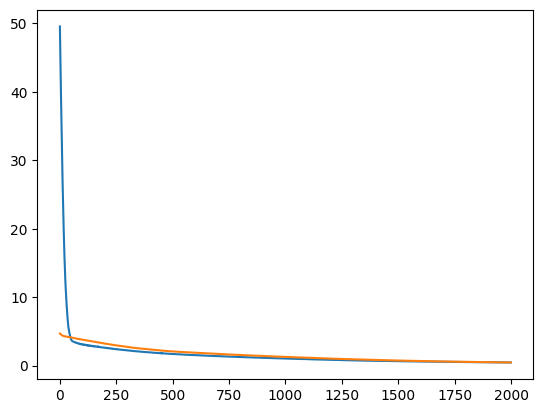

In [25]:
plt.plot(train_losses)
plt.plot(val_losses)

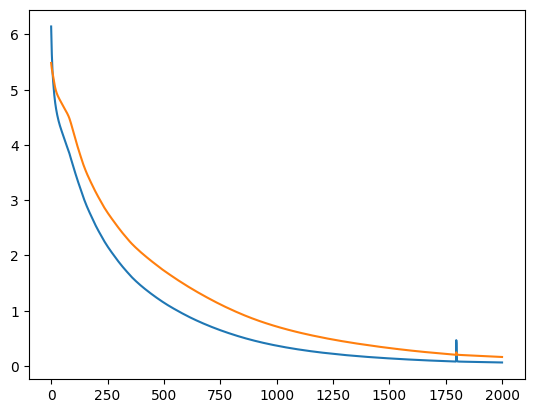

In [25]:
plt.plot(train_losses)
plt.plot(val_losses)

In [26]:
model.eval()
correct = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    outputs_class = nn.functional.softmax(outputs).argmax()
    labels_class = labels.argmax()
    correct += (outputs_class == labels_class)*1
acc = float(correct / len(test_loader))

/tmp/ipykernel_3887/3545108458.py:6: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  outputs_class = nn.functional.softmax(outputs).argmax()


In [27]:
acc

0.9122807383537292

In [28]:
#(29,50), (50, y.shape[1]), real, keep_sample_together=False, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.884
#(29,50), (50, y.shape[1]), simulated, keep_sample_together=False, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.561
#(29,50), (50,50), (50, y.shape[1]), real, keep_sample_together=False, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.878
#(29,50), (50,50), (50, y.shape[1]), simulated, keep_sample_together=False, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.667
#(29,50), (50,50), (50, y.shape[1]), real, keep_sample_together=True, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.887
#(29,50), Dropout, (50,50), (50, y.shape[1]), real, keep_sample_together=True, remove_outliers=False, 1000 epoch, lr=0.0001, Adam: acc=0.80
#(29,50), (50,50), (50, y.shape[1]), real, keep_sample_together=True, remove_outliers=False, 2000 epoch, lr=0.0001, Adam: acc=0.980
#(29,50), (50,50), (50, y.shape[1]), simulated, keep_sample_together=True, remove_outliers=False, 2000 epoch, lr=0.0001, Adam: acc=0.912